In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()
input_name = next(iter(uploaded))
input_path = '/content/' + input_name

print('Input Image:', input_name)

Saving Adad.jpg to Adad.jpg
Input Image: Adad.jpg


In [3]:
image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
if image is None:
  raise ValueError('The Input Image Could Not Be Loaded')

blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

threshold_value, binary_digits = cv2.threshold(blurred_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print('Threshold Value:', threshold_value)

Threshold Value: 182.0


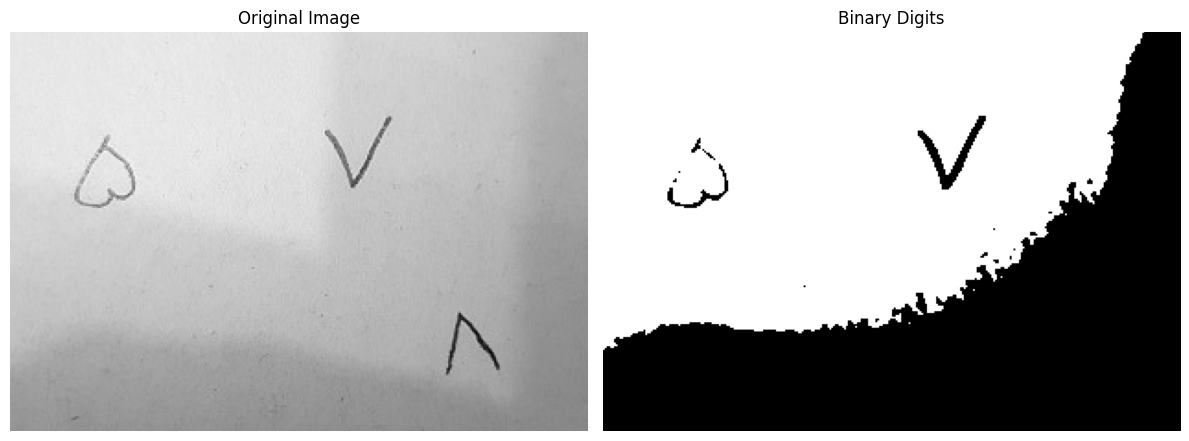

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_digits, cmap='gray')
plt.title('Binary Digits')
plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_digits, connectivity=8)

number_of_digits = num_labels - 1

print('Total Labels Including Background:', num_labels)
print('Number Of Connected Digits:', number_of_digits)

Total Labels Including Background: 7
Number Of Connected Digits: 6


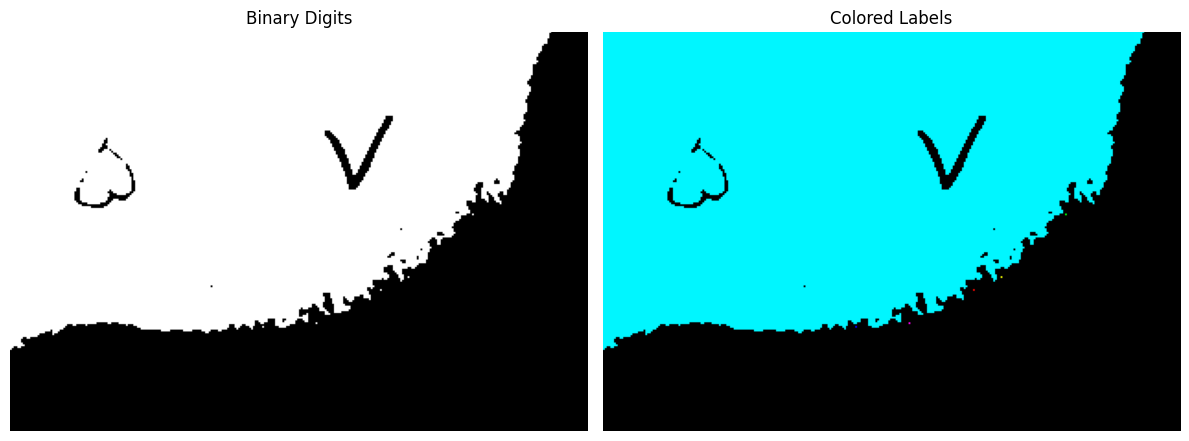

In [7]:
max_label = max(int(np.max(labels)), -1)
label_hue = np.uint8(179 * labels / np.max(labels))
blank_ch = 255 * np.ones_like(binary_digits)
colored_labels = cv2.merge([label_hue, blank_ch, blank_ch])
colored_labels = cv2.cvtColor(colored_labels, cv2.COLOR_HSV2BGR)
colored_labels[label_hue == 0] = 0

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(binary_digits, cmap='gray')
plt.title('Binary Digits')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(colored_labels)
plt.title('Colored Labels')
plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
print('Component Information:')

for component_id in range(1, num_labels):
  x, y, w, h, area = stats[component_id]
  print(
      f'Digit {component_id}: '
      f'x={x}, y={y}, width={w}, '
      f'height={h}, area={area}'
  )

Component Information:
Digit 1: x=0, y=0, width=294, height=173, area=39841
Digit 2: x=251, y=99, width=1, height=1, area=1
Digit 3: x=216, y=133, width=1, height=1, area=1
Digit 4: x=201, y=140, width=1, height=1, area=1
Digit 5: x=166, y=158, width=1, height=1, area=1
Digit 6: x=137, y=160, width=1, height=1, area=1


In [10]:
binary_output_path = '/content/Adad_digits_binary.png'
components_output_path = '/content/Adad_connected_components.png'

cv2.imwrite(binary_output_path, binary_digits)
cv2.imwrite(components_output_path, cv2.cvtColor(colored_labels, cv2.COLOR_RGB2BGR))

print('Saved:', binary_output_path)
print('Saved:', components_output_path)

Saved: /content/Adad_digits_binary.png
Saved: /content/Adad_connected_components.png


In [12]:
min_area = 100
filtered_digits = np.zeros_like(binary_digits)
kept_component_ids = []

for component_id in range(1, num_labels):
  area = stats[component_id, cv2.CC_STAT_AREA]

  if area >= min_area:
    filtered_digits[labels == component_id] = 255
    kept_component_ids.append(component_id)

filtered_num_labels, filtered_labels, filtered_stats, filtered_centroids = cv2.connectedComponentsWithStats(filtered_digits, connectivity=8)

filtered_number_of_digits = filtered_num_labels - 1

print('Minimum Component Area:', min_area)
print('Components Before Filtering:', number_of_digits)
print('Components After Filtering:', filtered_number_of_digits)

Minimum Component Area: 100
Components Before Filtering: 6
Components After Filtering: 1


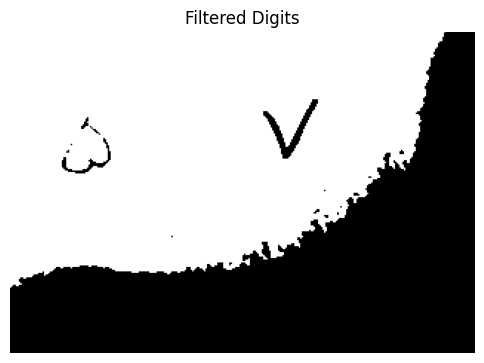

In [13]:
plt.figure(figsize=(6, 5))

plt.imshow(filtered_digits, cmap='gray')
plt.title('Filtered Digits')
plt.axis('off')

plt.show()

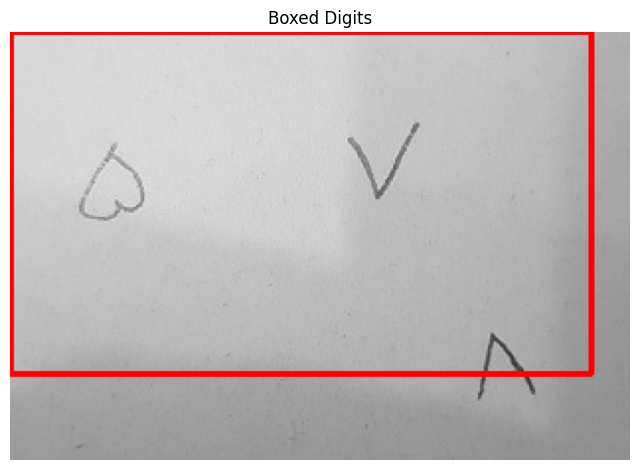

In [14]:
boxed_image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

for component_id in range(1, filtered_num_labels):
  x = filtered_stats[component_id, cv2.CC_STAT_LEFT]
  y = filtered_stats[component_id, cv2.CC_STAT_TOP]
  w = filtered_stats[component_id, cv2.CC_STAT_WIDTH]
  h = filtered_stats[component_id, cv2.CC_STAT_HEIGHT]

  cv2.rectangle(boxed_image, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.figure(figsize=(8, 6))

plt.imshow(boxed_image)
plt.title('Boxed Digits')
plt.axis('off')

plt.show()

In [17]:
component_data = []

for component_id in range(1, filtered_num_labels):
  x = filtered_stats[component_id, cv2.CC_STAT_LEFT]
  y = filtered_stats[component_id, cv2.CC_STAT_TOP]
  w = filtered_stats[component_id, cv2.CC_STAT_WIDTH]
  h = filtered_stats[component_id, cv2.CC_STAT_HEIGHT]
  area = filtered_stats[component_id, cv2.CC_STAT_AREA]
  center_x = int(filtered_centroids[component_id, 0])

  component_data.append({
      'component_id': component_id,
      'x': int(x),
      'y': int(y),
      'width': int(w),
      'height': int(h),
      'area': int(area),
      'center_x': float(center_x)
  })

sorted_component_data = sorted(component_data, key=lambda x: x['center_x'])

print('Components Ordered From Left To Right:')

for order, component in enumerate(sorted_component_data, start=1):
  print(
      f'Position {order}: '
      f'x={component["x"]}, '
      f'center_x={component["center_x"]:.2f}, '
      f'area={component["area"]}'
  )

Components Ordered From Left To Right:
Position 1: x=0, center_x=127.00, area=39841


In [20]:
expected_digit_count = 3

print('Expected Digit Count:', expected_digit_count)
print('Detected Digit Count:', filtered_number_of_digits)

if filtered_number_of_digits == expected_digit_count:
  print('Count Check Passed.')

else:
  print('Count Check Needs Adjustment.')
  print('Try Changing min_area And Run The Filtering Cells Again.')

Expected Digit Count: 3
Detected Digit Count: 1
Count Check Needs Adjustment.
Try Changing min_area And Run The Filtering Cells Again.
